# Auto ML Demo Notebook

这个 Notebook 用于演示一条完整的 AutoML 展示链路：
1. 使用 `kagglehub` 下载数据并显示路径
2. 触发一次工作流运行，并在运行中实时打印 run memory 状态
3. 展示当前使用的 DeepSeek 接口
4. 展示生成代码片段
5. 展示图表

In [1]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
from kagglehub import KaggleDatasetAdapter

PROJECT_ROOT = Path.cwd()
RUNS_DIR = PROJECT_ROOT / "runs"
print("Project root:", PROJECT_ROOT)

Project root: d:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle


d:\Programs\anaconda3\envs\agent1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) 从 Kaggle 下载数据


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail-ii")
download_dir = Path(path)

csv_files = sorted(download_dir.glob("**/*.csv"))
if not csv_files:
    raise RuntimeError(f"No CSV file found under: {download_dir}")

# 优先锁定本数据集的主文件名，避免后续单元“随便选”。
preferred_names = ["online_retail_II.csv", "Online Retail II.csv"]
DATA_CSV_PATH = None
for fname in preferred_names:
    matches = [p for p in csv_files if p.name == fname]
    if matches:
        DATA_CSV_PATH = matches[0]
        break

if DATA_CSV_PATH is None:
    if len(csv_files) == 1:
        DATA_CSV_PATH = csv_files[0]
    else:
        print("Found multiple CSV files:")
        for p in csv_files:
            print("-", p)
        raise RuntimeError("Multiple CSV files found; please specify which one to use.")

print("Path to dataset files:", path)
print("Selected CSV:", DATA_CSV_PATH)

Path to dataset files: C:\Users\QC\.cache\kagglehub\datasets\tunguz\online-retail-ii\versions\1
Selected CSV: C:\Users\QC\.cache\kagglehub\datasets\tunguz\online-retail-ii\versions\1\online_retail_II.csv


## 2) 展示当前使用的接口

In [3]:
deepseek_base_url = os.environ.get("DEEPSEEK_BASE_URL", "https://api.deepseek.com")
deepseek_model = os.environ.get("DEEPSEEK_MODEL", "deepseek-chat")

print("DeepSeek interface in use:")
print("- base_url:", deepseek_base_url)
print("- model:", deepseek_model)

DeepSeek interface in use:
- base_url: https://api.deepseek.com
- model: deepseek-chat


## 3) 运行工作流

In [4]:
CONFIG_PATH = "configs/kaggle retail.yaml"
RUN_ID = f"demo_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# 使用第 4 个单元已锁定的 CSV，不再二次猜测。
if "DATA_CSV_PATH" not in globals():
    raise RuntimeError("DATA_CSV_PATH is missing. Please run cell 4 first.")
data_csv = Path(DATA_CSV_PATH)
if not data_csv.exists():
    raise RuntimeError(f"Selected CSV not found: {data_csv}")
print("Using Kaggle CSV:", data_csv)

env = os.environ.copy()
env["KAGGLE_DATA_PATH"] = str(data_csv)
env.setdefault("KAGGLE_TARGET", "Quantity")
env.setdefault("KAGGLE_TASK_TYPE", "regression")

cmd = [
    sys.executable,
    "-m",
    "src.cli",
    "run",
    "--foreground",
    "--config",
    CONFIG_PATH,
    "--run-id",
    RUN_ID,
 ]
print("Running:", " ".join(cmd))

process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    env=env,
 )

import queue
import threading
import time

run_dir = RUNS_DIR / RUN_ID
mem_path = run_dir / "run_memory.jsonl"
seen_mem_lines = 0
stdout_queue: "queue.Queue[str]" = queue.Queue()

def _pump_stdout(pipe, out_q):
    if pipe is None:
        return
    for ln in iter(pipe.readline, ""):
        out_q.put(ln)
    try:
        pipe.close()
    except Exception:
        pass

pump_thread = threading.Thread(
    target=_pump_stdout,
    args=(process.stdout, stdout_queue),
    daemon=True,
 )
pump_thread.start()

while True:
    while True:
        try:
            ln = stdout_queue.get_nowait()
        except queue.Empty:
            break
        print(ln, end="")

    if mem_path.exists():
        mem_lines = mem_path.read_text(encoding="utf-8").splitlines()
        if len(mem_lines) > seen_mem_lines:
            for raw in mem_lines[seen_mem_lines:]:
                try:
                    rec = json.loads(raw)
                except Exception:
                    continue

                rtype = rec.get("type")
                state = rec.get("state")
                if rtype == "state_enter":
                    print(f"[run_memory] ENTER {state} | attempt={rec.get('attempt')}")
                elif rtype == "state_exit":
                    print(f"[run_memory] EXIT  {state} | ok={rec.get('ok')}")
                elif rtype == "decision":
                    print(f"[run_memory] DECISION in {state}: target={rec.get('target')}")

            seen_mem_lines = len(mem_lines)

    if process.poll() is not None and stdout_queue.empty():
        break
    time.sleep(0.2)

return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"Workflow run failed with code={return_code}")

RUN_DIR = run_dir
if not RUN_DIR.exists():
    raise RuntimeError(f"Expected run dir not found: {RUN_DIR}")
print("Using run dir:", RUN_DIR)

Using Kaggle CSV: C:\Users\QC\.cache\kagglehub\datasets\tunguz\online-retail-ii\versions\1\online_retail_II.csv
Running: d:\Programs\anaconda3\envs\agent1\python.exe -m src.cli run --foreground --config configs/kaggle retail.yaml --run-id demo_20260410_130121
Submitted run: demo_20260410_130121
Mode: foreground
Run dir: D:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle\runs\demo_20260410_130121
[workflow] run started | run_dir=D:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle\runs\demo_20260410_130121
Init (to chat_manager):

Please help me to build a model to predict target `Quantity`.
- Task type: regression
- The dataset is available at: `C:\Users\QC\.cache\kagglehub\datasets\tunguz\online-retail-ii\versions\1\online_retail_II.csv`.
- All code will be executed in a Jupyter notebook, where previous states are saved.
- Save ALL plot/image files under: `D:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle\runs\demo_20260410_13012

KeyboardInterrupt: 

## 4) 展示生成代码（若干行）

In [9]:
if "RUN_DIR" not in globals():
    demo_runs = sorted(
        [p for p in RUNS_DIR.iterdir() if p.is_dir() and p.name.startswith("demo_")],
        key=lambda p: p.name,
    )
    if not demo_runs:
        raise RuntimeError("RUN_DIR is missing and no demo_* run found. Please run cell 8 first.")
    RUN_DIR = demo_runs[-1]
    print("RUN_DIR missing, fallback to latest demo run:", RUN_DIR)

coding_dir = RUN_DIR / "coding"
code_candidates = []
if (coding_dir / "train.py").exists():
    code_candidates.append(coding_dir / "train.py")

numbered = sorted(coding_dir.glob("[0-9][0-9][0-9]_*.py"))
code_candidates.extend(numbered[::-1])  # 最新优先

if not code_candidates:
    print("No generated python code found in coding/.")
else:
    code_file = code_candidates[0]
    print("Showing code from:", code_file.name)
    lines = code_file.read_text(encoding="utf-8").splitlines()
    preview_n = min(60, len(lines))
    for i, ln in enumerate(lines[:preview_n], start=1):
        print(f"{i:>3}: {ln}")

Showing code from: train.py
  1: import pandas as pd
  2: import numpy as np
  3: import matplotlib.pyplot as plt
  4: import seaborn as sns
  5: from sklearn.model_selection import train_test_split
  6: from sklearn.preprocessing import StandardScaler, OneHotEncoder
  7: from sklearn.compose import ColumnTransformer
  8: from sklearn.pipeline import Pipeline
  9: from sklearn.impute import SimpleImputer
 10: from sklearn.linear_model import LinearRegression
 11: from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 12: import joblib
 13: import warnings
 14: warnings.filterwarnings('ignore')
 15: from pathlib import Path
 16: 
 17: # Set paths for saving outputs
 18: plot_dir = Path(r"D:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle\runs\demo_20260410_130121\plot")
 19: data_dir = Path(r"D:\Learning\Agent\Auto_ML_Agent\build-with-ag2\automate-ml-for-kaggle\runs\demo_20260410_130121\data")
 20: 
 21: # Create directories if they don't exist

## 5) 展示图表

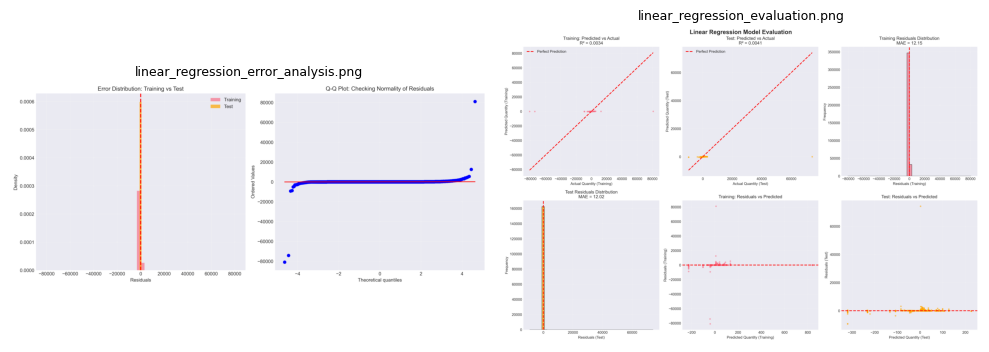

In [10]:
if "RUN_DIR" not in globals():
    demo_runs = sorted(
        [p for p in RUNS_DIR.iterdir() if p.is_dir() and p.name.startswith("demo_")],
        key=lambda p: p.name,
    )
    if not demo_runs:
        raise RuntimeError("RUN_DIR is missing and no demo_* run found. Please run cell 8 first.")
    RUN_DIR = demo_runs[-1]
    print("RUN_DIR missing, fallback to latest demo run:", RUN_DIR)

plot_dir = RUN_DIR / "plot"
image_exts = {".png", ".jpg", ".jpeg", ".webp", ".gif", ".svg"}
image_files = []
if plot_dir.exists():
    image_files = [p for p in sorted(plot_dir.iterdir()) if p.suffix.lower() in image_exts]

if not image_files:
    print("No plot images found in plot/.")
else:
    max_show = min(4, len(image_files))
    fig, axes = plt.subplots(1, max_show, figsize=(5 * max_show, 4))
    if max_show == 1:
        axes = [axes]

    for ax, img_path in zip(axes, image_files[:max_show]):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    if len(image_files) > max_show:
        print(f"Shown {max_show}/{len(image_files)} images.")